# Proyecto Machine Learning: Calidad de Vino con XGBoost

## Descripción del Proyecto
Este proyecto tiene como objetivo predecir si un vino es de buena o mala calidad utilizando el algoritmo **XGBoost**. 

El modelo entrenado analiza las características físico-químicas del producto para clasificarlo automáticamente, optimizando los procesos de control de calidad en la producción vitivinícola.

---

### Características Químicas del Vino (Features)
El modelo utilizará variables analíticas clave, tales como:
* Acidez fija
* Acidez volátil
* Ácido cítrico
* Azúcar residual
* Cloruros
* Dióxido de azufre (libre y total)
* Densidad
* pH
* Sulfatos
* Alcohol

### Variable Objetivo (Target)
La calidad del vino se evaluará mediante una clasificación binaria:
* **1** = Vino Bueno
* **0** = Vino Malo

### Tecnologías y Librerías Utilizadas
* **Python**: Lenguaje principal de desarrollo.
* **Pandas & NumPy**: Manipulación, limpieza y análisis exploratorio de datos.
* **Scikit-Learn**: Preprocesamiento de datos, escalado y métricas de evaluación del modelo.
* **XGBoost**: Algoritmo de Gradient Boosting para el entrenamiento del clasificador de alta precisión.
* **Joblib**: Serialización y guardado del modelo entrenado para su posterior producción.
* **Streamlit**: Creación de una interfaz web interactiva para desplegar el modelo en tiempo real.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier

import joblib

# Carga de Dateset
En este paso se cargó el dataset que contiene la información de los vinos.

La función pd.read_csv() se utilizó para leer el archivo CSV y guardar los datos en una variable llamada df, que funciona como una tabla dentro de Python.

Después, con df.head(), se mostraron las primeras filas del dataset. Esto se hizo para comprobar que el archivo se cargó correctamente y revisar rápidamente cómo están organizados los datos, las columnas y algunos valores iniciales.

In [3]:
# Cargar dataset

df = pd.read_csv('/workspaces/calidad-vino-xgboost/data/raw/calidad_de_vino.csv')

# Mostrar primeras filas
print(df.head())


   botella_id  acidez fija  acidez volatil  acido citrico  azucar residual  \
0           0          9.5            0.56           0.33              2.4   
1           1          6.6            0.24           0.28              1.8   
2           2          9.4            0.59           0.14              2.0   
3           3          6.1            0.32           0.33             10.7   
4           4          7.0            0.36           0.35              2.5   

   cloruros  dioxido de azufre libre  dioxido de azufre total  densidad    pH  \
0     0.089                     35.0                     67.0   0.99720  3.28   
1     0.028                     39.0                    132.0   0.99182  3.34   
2     0.084                     25.0                     48.0   0.99810  3.14   
3     0.036                     27.0                     98.0   0.99521  3.34   
4     0.048                     67.0                    161.0   0.99146  3.05   

   sulfatos  alcohol   color  calidad  
0   

# Informacion del Dataset "Calidad de vinos"
En este paso se revisó la información general del dataset utilizando df.info().

Esta función permitió ver cuántas filas y columnas tiene el archivo, qué tipo de datos contiene cada columna y si existen valores vacíos o nulos.

Con esto se puede entender mejor la estructura de los datos antes de comenzar el análisis o el entrenamiento del modelo, además de ayudar a detectar posibles problemas en el dataset.

In [4]:
# Información General del Dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   botella_id               6497 non-null   int64  
 1   acidez fija              6497 non-null   float64
 2   acidez volatil           6497 non-null   float64
 3   acido citrico            6497 non-null   float64
 4   azucar residual          6497 non-null   float64
 5   cloruros                 6497 non-null   float64
 6   dioxido de azufre libre  6497 non-null   float64
 7   dioxido de azufre total  6497 non-null   float64
 8   densidad                 6497 non-null   float64
 9   pH                       6497 non-null   float64
 10  sulfatos                 6497 non-null   float64
 11  alcohol                  6497 non-null   float64
 12  color                    6497 non-null   str    
 13  calidad                  6497 non-null   int64  
dtypes: float64(11), int64(2), str(1)
me

# Estadisticas
En este paso se generaron estadísticas descriptivas del dataset usando df.describe().

La función mostró información importante de las variables numéricas, como el promedio, la desviación estándar, los valores mínimos y máximos, entre otros datos estadísticos.

Esto ayudó a tener una idea general del comportamiento de los datos y permitió identificar posibles valores extremos, diferencias grandes entre datos o posibles outliers que podrían afectar el rendimiento del modelo.

In [5]:
# Estadísticas Descriptivas
print(df.describe())

        botella_id  acidez fija  acidez volatil  acido citrico  \
count  6497.000000  6497.000000     6497.000000    6497.000000   
mean   3248.000000     7.215307        0.339666       0.318633   
std    1875.666681     1.296434        0.164636       0.145318   
min       0.000000     3.800000        0.080000       0.000000   
25%    1624.000000     6.400000        0.230000       0.250000   
50%    3248.000000     7.000000        0.290000       0.310000   
75%    4872.000000     7.700000        0.400000       0.390000   
max    6496.000000    15.900000        1.580000       1.660000   

       azucar residual     cloruros  dioxido de azufre libre  \
count      6497.000000  6497.000000              6497.000000   
mean          5.443235     0.056034                30.525319   
std           4.757804     0.035034                17.749400   
min           0.600000     0.009000                 1.000000   
25%           1.800000     0.038000                17.000000   
50%           3.00000

# Posibles valores nulos
En este paso se verificó si el dataset tenía valores nulos o vacíos.

La función isnull() identificó los espacios sin información y sum() contó cuántos había en cada columna.

Esto es importante porque los valores faltantes pueden generar errores o afectar el entrenamiento del modelo, por lo que primero se debe comprobar si existen antes de continuar con el análisis.

In [6]:
# Verificar Valores Nulos
print(df.isnull().sum())

botella_id                 0
acidez fija                0
acidez volatil             0
acido citrico              0
azucar residual            0
cloruros                   0
dioxido de azufre libre    0
dioxido de azufre total    0
densidad                   0
pH                         0
sulfatos                   0
alcohol                    0
color                      0
calidad                    0
dtype: int64


# Variable objetivo
En este paso se creó una gráfica para observar cómo se distribuyen las categorías de calidad del vino.

Con countplot se contó cuántos registros existen para cada valor de la columna calidad, mostrando visualmente cuáles aparecen más y cuáles menos.

Esto permitió identificar si el dataset estaba balanceado o si algunas categorías tenían muchos más datos que otras, algo importante porque puede influir en el rendimiento y precisión del modelo.

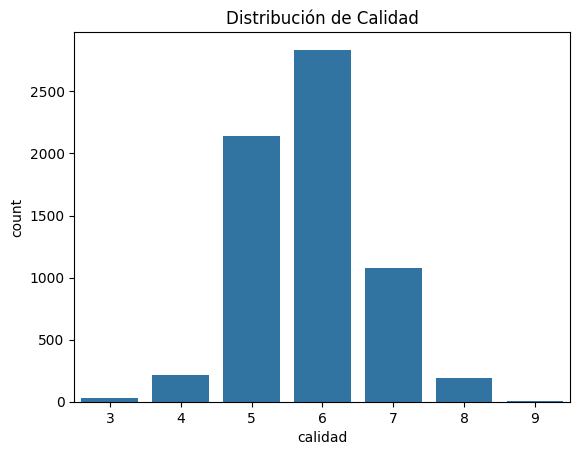

In [7]:
# Exploración de la Variable Objetivo
sns.countplot(x='calidad', data=df)
plt.title('Distribución de Calidad')
plt.show()

# Organizacion y preparacion de las variables
En esta parte se prepararon los datos para poder entrenar el modelo de Machine Learning.

Primero, el problema se convirtió en una clasificación binaria, es decir, solo se definieron dos resultados:

* 1 para vinos considerados buenos.
* 0 para vinos considerados malos.

Esto se hizo tomando la columna calidad, donde los vinos con calidad mayor o igual a 6 fueron marcados como buenos.

Luego se eliminaron columnas que no aportaban al análisis, como:

* botella_id, porque solo era un identificador.
* calidad, porque ya se había transformado en la nueva variable vino_bueno.

Después, la columna color se convirtió a valores numéricos para que el modelo pudiera entenderla, ya que los algoritmos trabajan mejor con números.

Más adelante se separaron los datos en:

* X: las características del vino.
* y: la variable objetivo (vino_bueno).

Luego el dataset se dividió en dos partes:

* Entrenamiento (80%), para enseñar al modelo.
* Prueba (20%), para evaluar qué tan bien funciona con datos nuevos.

Finalmente, se aplicó un escalado de datos usando StandardScaler. Esto normalizó los valores para que todas las variables estuvieran en rangos similares, ayudando a que el modelo aprendiera de manera más eficiente y estable.

In [8]:
# Convertir el Problema a Clasificación Binaria
# Crear nueva columna objetivo
# 1 = vino bueno
# 0 = vino malo
df['vino_bueno'] = (df['calidad'] >= 6).astype(int)

# Eliminar columnas que no ayudan
df = df.drop(['botella_id', 'calidad'], axis=1)

# Convertir color a valores numéricos
df = pd.get_dummies(df, columns=['color'], drop_first=True)

# Separar Variables X e y
# X: contiene las características.
# Y: contiene la variable objetivo.
X = df.drop('vino_bueno', axis=1)
y = df['vino_bueno']

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Escalado de Datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creacion del modelo XGboost
En este paso se creó el modelo XGBoost, que será el encargado de aprender de los datos y clasificar si un vino es bueno o malo.

También se ajustaron algunas configuraciones:

n_estimators=200: cantidad de veces que el modelo aprende.
learning_rate=0.05: velocidad con la que aprende.
max_depth=5: qué tan complejas pueden ser las decisiones del modelo.

In [9]:
# Creacion del Modelo XGBoost
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# Entrenamiento, predicciones y precision del algoritmo
En este paso el modelo fue entrenado utilizando los datos preparados anteriormente.
Con model.fit() el algoritmo aprendió patrones y relaciones entre las características químicas del vino y su calidad.

Después, el modelo realizó predicciones sobre los datos de prueba usando model.predict().
Esto permitió comprobar cómo se comporta el modelo con información nueva que no había visto antes.

Finalmente, se calculó el accuracy, que muestra el porcentaje de predicciones correctas realizadas por el modelo al comparar los resultados reales con los predichos.

In [10]:
# Entrenamiendo del modelo mediante 'model.fit'
model.fit(X_train_scaled, y_train)

# Predicciones referentes al modelo
y_pred = model.predict(X_test_scaled)

#Precision de las predicciones
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.7746153846153846


# Reportes de clasificacion
En este paso se generó un reporte de clasificación para evaluar el rendimiento del modelo de manera más detallada.

El reporte mostró métricas como:

* precision: qué tan precisas fueron las predicciones.
* recall: qué tantos casos correctos logró detectar el modelo.
* f1-score: equilibrio entre precisión y recall.

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.65      0.68       481
           1       0.80      0.85      0.83       819

    accuracy                           0.77      1300
   macro avg       0.76      0.75      0.75      1300
weighted avg       0.77      0.77      0.77      1300



# Matriz de confusion

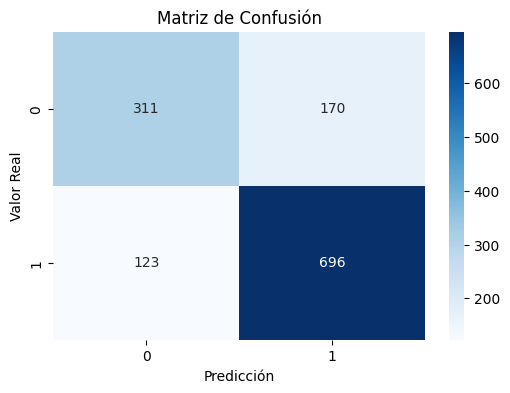

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Detalles de la curva ROC
En este paso se creó la curva ROC para evaluar qué tan bien el modelo diferencia entre vinos buenos y malos.

Primero, el modelo calculó las probabilidades de cada predicción y luego se generó una gráfica comparando los aciertos y errores del modelo.

La curva ROC ayuda a medir la capacidad de clasificación del modelo.
Mientras más cerca esté la línea de la esquina superior izquierda, mejor será el rendimiento del modelo al separar las clases correctamente.

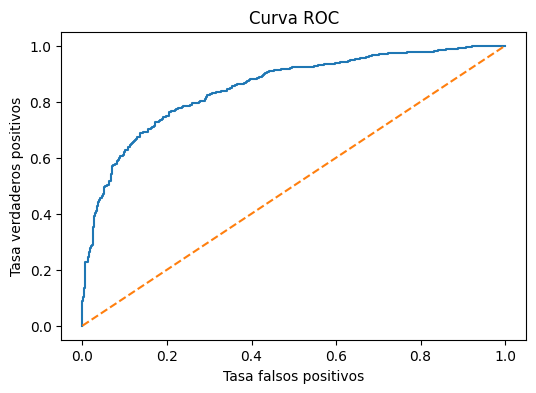

In [24]:
y_probs = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title('Curva ROC')
plt.xlabel('Tasa falsos positivos')
plt.ylabel('Tasa verdaderos positivos')
plt.show()

# Jerarquia de las variables
En este paso se analizó cuáles variables fueron las más importantes para el modelo.

XGBoost calculó qué características del vino influyeron más en las predicciones y luego se mostraron en una gráfica de barras.

Esto permitió identificar cuáles variables tuvieron mayor impacto al momento de clasificar si un vino era bueno o malo, ayudando a entender mejor cómo toma decisiones el modelo.

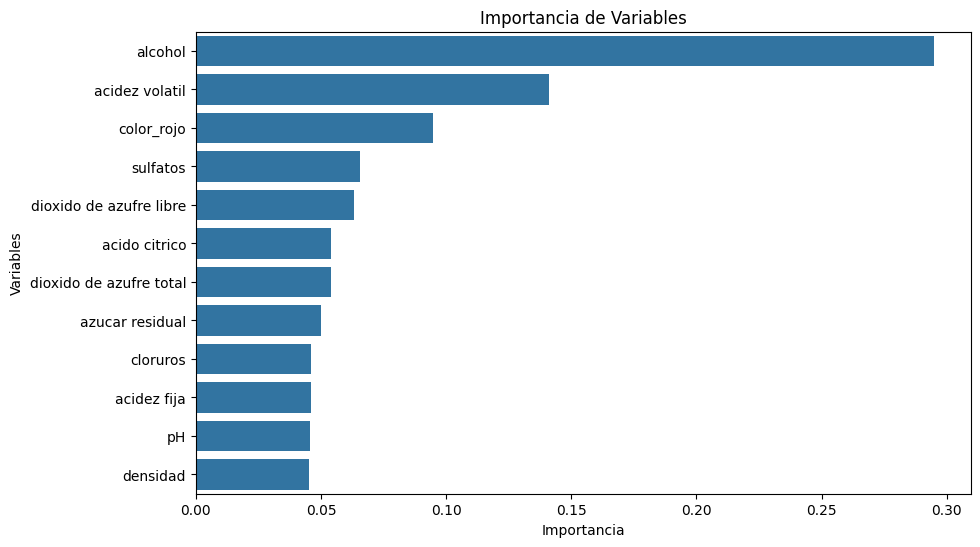

In [22]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Variables': features,
    'Importancia': importances
})

importance_df = importance_df.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importancia', y='Variables', data=importance_df)
plt.title('Importancia de Variables')
plt.show()

In [15]:
import os

# Crear carpeta models
os.makedirs('/workspaces/calidad-vino-xgboost/models', exist_ok=True)

In [16]:
import joblib

# Guardar modelo
joblib.dump(model, '/workspaces/calidad-vino-xgboost/models/modelo.pkl')

# Guardar scaler
joblib.dump(scaler, '/workspaces/calidad-vino-xgboost/models/scaler.pkl')

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [17]:
import json

with open("/workspaces/calidad-vino-xgboost/models/features.json", "w") as f:
    json.dump(list(X.columns), f)